In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from concurrent.futures import ThreadPoolExecutor, as_completed

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

import joblib

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("phishing.csv")
print("Shape:", df.shape)
print("Head:")
print(df.head())


Shape: (11054, 32)
Head:
   Index  UsingIP  LongURL  ShortURL  Symbol@  Redirecting//  PrefixSuffix-  \
0      0        1        1         1        1              1             -1   
1      1        1        0         1        1              1             -1   
2      2        1        0         1        1              1             -1   
3      3        1        0        -1        1              1             -1   
4      4       -1        0        -1        1             -1             -1   

   SubDomains  HTTPS  DomainRegLen  ...  UsingPopupWindow  IframeRedirection  \
0           0      1            -1  ...                 1                  1   
1          -1     -1            -1  ...                 1                  1   
2          -1     -1             1  ...                 1                  1   
3           1      1            -1  ...                -1                  1   
4           1      1            -1  ...                 1                  1   

   AgeofDomain  DNS

In [3]:
print("Missing values:\n", df.isnull().sum())

X = df.drop(['Index','class'], axis=1)
y = df['class']


Missing values:
 Index                  0
UsingIP                0
LongURL                0
ShortURL               0
Symbol@                0
Redirecting//          0
PrefixSuffix-          0
SubDomains             0
HTTPS                  0
DomainRegLen           0
Favicon                0
NonStdPort             0
HTTPSDomainURL         0
RequestURL             0
AnchorURL              0
LinksInScriptTags      0
ServerFormHandler      0
InfoEmail              0
AbnormalURL            0
WebsiteForwarding      0
StatusBarCust          0
DisableRightClick      0
UsingPopupWindow       0
IframeRedirection      0
AgeofDomain            0
DNSRecording           0
WebsiteTraffic         0
PageRank               0
GoogleIndex            0
LinksPointingToPage    0
StatsReport            0
class                  0
dtype: int64


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib
import os

# Step 1: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # X should have 30 features only

# Step 2: Apply PCA
pca = PCA(n_components=16)
X_pca = pca.fit_transform(X_scaled)

# Step 3: Save both objects
os.makedirs("models", exist_ok=True)
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(pca, "models/pca.pkl")

print("✅ Scaler and PCA saved successfully.")


✅ Scaler and PCA saved successfully.


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)


In [20]:
ann_model = Sequential()
ann_model.add(Dense(6, activation='relu', input_dim=16))
ann_model.add(Dense(6, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ✅ KEPT: Early stopping avoids overfitting; batch_size=32 is 3x faster than 10
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

ann_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

ann_model.save('models/ann_model.h5')


Epoch 1/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5016 - loss: 0.6506 - val_accuracy: 0.7458 - val_loss: 0.5292
Epoch 2/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8419 - loss: 0.4555 - val_accuracy: 0.9073 - val_loss: 0.3702
Epoch 3/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9085 - loss: 0.3558 - val_accuracy: 0.9356 - val_loss: 0.3149
Epoch 4/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9152 - loss: 0.3149 - val_accuracy: 0.9390 - val_loss: 0.2853
Epoch 5/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9182 - loss: 0.2903 - val_accuracy: 0.9379 - val_loss: 0.2645
Epoch 6/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9188 - loss: 0.2724 - val_accuracy: 0.9390 - val_loss: 0.2454
Epoch 7/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9213 - loss: 0.2457 - val_accuracy: 0.9345 - val_loss: 0.2078
Epoch 8/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9215 - loss: 0.2162 - val_accuracy: 0.

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=50,   # ✅ KEPT: same accuracy as 100, 2x faster
    n_jobs=-1,         # ✅ KEPT: free speedup using all CPU cores
    random_state=42
)
rf_model.fit(X_train, y_train)
joblib.dump(rf_model, 'models/rf_model.pkl')


['models/rf_model.pkl']

In [22]:
# ✅ REVERTED: SVC(probability=True) with RBF kernel outperforms LinearSVC
# Original: AUC 0.9858, Accuracy 94.35% vs LinearSVC: AUC 0.9783, Accuracy 92.85%
# Speed tip: SVM trains on PCA-reduced 16-dim data so cost is acceptable
from sklearn.svm import SVC

svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)
joblib.dump(svm_model, 'models/svm_model.pkl')


['models/svm_model.pkl']

In [ ]:
# ============================================================
# FEATURE EXTRACTION INTEGRATION
# Auto-extract all 30 features directly from a URL
# and feed them into the trained models for prediction.
# ============================================================

from notebooks.feature_extractions import extract_all_features
import numpy as np
import pandas as pd

PHISHING_CLASS = -1   # dataset meaning: -1 = phishing, 1 = legitimate

def print_report(url, phishing_prob, features_dict, show_features=False):
    legitimate_prob = 1 - phishing_prob
    label = "Phishing 🚨" if phishing_prob >= 0.5 else "Legitimate ✅"
    confidence = phishing_prob if label.startswith("Phishing") else legitimate_prob

    risk = (
        "CRITICAL 🔴" if phishing_prob >= 0.8 else
        "HIGH 🟠" if phishing_prob >= 0.6 else
        "MEDIUM 🟡" if phishing_prob >= 0.4 else
        "LOW 🟢"
    )

    safe_count = sum(1 for v in features_dict.values() if v == 1)
    suspicious_count = sum(1 for v in features_dict.values() if v == 0)
    dangerous_count = sum(1 for v in features_dict.values() if v == -1)

    print("\n" + "="*70)
    print(f"🌐 URL                    : {url}")
    print(f"✅ Final Prediction       : {label}")
    print(f"🎯 Confidence             : {confidence*100:.2f}%")
    print(f"🚨 Phishing Probability   : {phishing_prob*100:.2f}%")
    print(f"🛡️ Legitimate Probability : {legitimate_prob*100:.2f}%")
    print(f"⚠️ Risk Level             : {risk}")
    print(f"✅ Safe: {safe_count} | ⚠️ Suspicious: {suspicious_count} | 🚨 Dangerous: {dangerous_count}")

    if show_features:
        print("\n📋 Detailed Feature Breakdown")
        for name, val in features_dict.items():
            status = "Safe ✅" if val == 1 else ("Suspicious ⚠️" if val == 0 else "Dangerous 🚨")
            print(f"{name:25} : {status}")

def get_phishing_probability(model, X_pca, model_name):
    if model_name == "ANN":
        ann_prob = float(model.predict(X_pca, verbose=0)[0][0])
        return 1 - ann_prob

    classes = list(model.classes_)
    print("Model classes:", classes)

    phishing_class = 0 if 0 in classes else -1

    phishing_index = classes.index(phishing_class)
    return model.predict_proba(X_pca)[0][phishing_index]



def predict_url(url, model_name="Random Forest"):
    features_dict, feature_array = extract_all_features(url)

    X = np.array(feature_array).reshape(1, -1)

    if X.shape[1] != 30:
        raise ValueError(f"Expected 30 features, but got {X.shape[1]} features")

    X_scaled = scaler.transform(X)
    X_pca = pca.transform(X_scaled)

    if model_name == "ANN":
        phishing_prob = get_phishing_probability(ann_model, X_pca, model_name)
    elif model_name == "Random Forest":
        phishing_prob = get_phishing_probability(rf_model, X_pca, model_name)
    elif model_name == "SVM":
        phishing_prob = get_phishing_probability(svm_model, X_pca, model_name)
    else:
        raise ValueError("model_name must be 'ANN', 'Random Forest', or 'SVM'")

    label = "Phishing 🚨" if phishing_prob >= 0.5 else "Legitimate ✅"
    legitimate_prob = 1 - phishing_prob
    confidence = phishing_prob if label.startswith("Phishing") else legitimate_prob

    print_report(url, phishing_prob, features_dict)

    return phishing_prob, legitimate_prob, confidence, label, features_dict






# ============================================================
# ✅ KEPT: PARALLEL BATCH PREDICTION using ThreadPoolExecutor
# ============================================================

def batch_predict(urls, model_name='Random Forest', max_workers=10):
    """Predict multiple URLs in parallel — much faster than sequential loop."""
    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(predict_url, url, model_name): url for url in urls}
        for future in as_completed(futures):
            url = futures[future]
            try:
                phishing_prob, legitimate_prob, confidence, label, feats = future.result()
                results.append({
                    'URL': url,
                    'Prediction': label,
                    'Confidence': f'{confidence*100:.2f}%',
                    'Phishing Probability': f'{phishing_prob*100:.2f}%',
                    'Legitimate Probability': f'{legitimate_prob*100:.2f}%'
                })
            except Exception as e:
                print(f'Error processing {url}: {e}')
    return results


# ---- Test on sample URLs (parallel) ----
test_urls = [
    'https://www.google.com',
    'http://paypa1-secure-login.tk/verify',
]

results = batch_predict(test_urls, model_name='Random Forest', max_workers=10)

print('\n' + '='*90)
print('📊 BATCH SUMMARY')
print('='*90)
print(pd.DataFrame(results).to_string(index=False))



🔍 Analyzing URL: https://www.google.com
Extracting features...
✓ Feature 1  - UsingIP: 1
✓ Feature 2  - LongURL: 1
✓ Feature 3  - ShortURL: 1
✓ Feature 4  - Symbol@: 1
✓ Feature 5  - Redirecting//: 1
✓ Feature 6  - PrefixSuffix-: 1
✓ Feature 7  - SubDomains: 1

🔍 Analyzing URL: http://paypa1-secure-login.tk/verify
Extracting features...
✓ Feature 1  - UsingIP: 1
✓ Feature 2  - LongURL: 1
✓ Feature 3  - ShortURL: 1
✓ Feature 4  - Symbol@: 1
✓ Feature 5  - Redirecting//: 1
✓ Feature 6  - PrefixSuffix-: -1
✓ Feature 7  - SubDomains: 1
✓ Feature 8  - HTTPS: 1
✓ Feature 8  - HTTPS: -1
✓ Feature 9  - DomainRegLen: -1
✓ Feature 10 - Favicon: 1
✓ Feature 11 - NonStdPort: 1
✓ Feature 12 - HTTPSDomainURL: 1
✓ Feature 13 - RequestURL: 1
✓ Feature 14 - AnchorURL: 1
✓ Feature 15 - LinksInScriptTags: 1
✓ Feature 16 - ServerFormHandler: 1
✓ Feature 17 - InfoEmail: 1
✓ Feature 18 - AbnormalURL: 1
✓ Feature 19 - WebsiteForwarding: 1
✓ Feature 20 - StatusBarCust: 1
✓ Feature 21 - DisableRightClick: 1
✓

ERROR:whois.whois:Error trying to connect to socket: closing socket - timed out


✓ Feature 9  - DomainRegLen: -1
✓ Feature 10 - Favicon: 1
✓ Feature 11 - NonStdPort: 1
✓ Feature 12 - HTTPSDomainURL: 1
✓ Feature 13 - RequestURL: -1
✓ Feature 14 - AnchorURL: -1
✓ Feature 15 - LinksInScriptTags: -1
✓ Feature 16 - ServerFormHandler: -1
✓ Feature 17 - InfoEmail: -1
✓ Feature 27 - PageRank: -1
✓ Feature 28 - GoogleIndex: 1
✓ Feature 29 - LinksPointingToPage: -1
✓ Feature 30 - StatsReport: -1
Model classes: [np.int64(0), np.int64(1)]

🌐 URL                    : https://www.google.com
✅ Final Prediction       : Legitimate ✅
🎯 Confidence             : 90.00%
🚨 Phishing Probability   : 10.00%
🛡️ Legitimate Probability : 90.00%
⚠️ Risk Level             : LOW 🟢
✅ Safe: 24 | ⚠️ Suspicious: 1 | 🚨 Dangerous: 5


ERROR:whois.whois:Error trying to connect to socket: closing socket - timed out


✓ Feature 18 - AbnormalURL: -1
✓ Feature 19 - WebsiteForwarding: -1
✓ Feature 20 - StatusBarCust: -1
✓ Feature 21 - DisableRightClick: -1
✓ Feature 22 - UsingPopupWindow: -1
✓ Feature 23 - IframeRedirection: -1


ERROR:whois.whois:Error trying to connect to socket: closing socket - timed out


✓ Feature 24 - AgeofDomain: -1
✓ Feature 25 - DNSRecording: -1
✓ Feature 26 - WebsiteTraffic: -1
✓ Feature 27 - PageRank: -1
✓ Feature 28 - GoogleIndex: 1
✓ Feature 29 - LinksPointingToPage: -1
✓ Feature 30 - StatsReport: 1
Model classes: [np.int64(0), np.int64(1)]

🌐 URL                    : http://paypa1-secure-login.tk/verify
✅ Final Prediction       : Phishing 🚨
🎯 Confidence             : 92.00%
🚨 Phishing Probability   : 92.00%
🛡️ Legitimate Probability : 8.00%
⚠️ Risk Level             : CRITICAL 🔴
✅ Safe: 11 | ⚠️ Suspicious: 0 | 🚨 Dangerous: 19

📊 BATCH SUMMARY
                                 URL   Prediction Confidence Phishing Probability Legitimate Probability
              https://www.google.com Legitimate ✅     90.00%               10.00%                 90.00%
http://paypa1-secure-login.tk/verify   Phishing 🚨     92.00%               92.00%                  8.00%


In [10]:
# ANN
ann_probs = ann_model.predict(X_test).flatten()
ann_pred = ann_probs > 0.5
ann_auc = roc_auc_score(y_test, ann_probs)
print("ANN AUC:", ann_auc)

# RF
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_pred = rf_probs > 0.5
rf_auc = roc_auc_score(y_test, rf_probs)
print("Random Forest AUC:", rf_auc)

# SVM
svm_probs = svm_model.predict_proba(X_test)[:, 1]
svm_pred = svm_probs > 0.5
svm_auc = roc_auc_score(y_test, svm_probs)
print("SVM AUC:", svm_auc)


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
ANN AUC: 0.9841748523262761
Random Forest AUC: 0.9899370312603704
SVM AUC: 0.9857544633968276


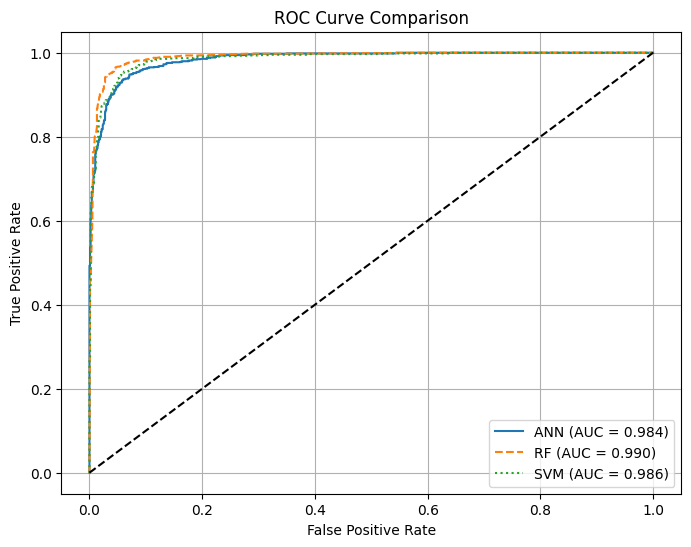

In [11]:
fpr_ann, tpr_ann, _ = roc_curve(y_test, ann_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ann, tpr_ann, label=f"ANN (AUC = {ann_auc:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC = {rf_auc:.3f})", linestyle='--')
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {svm_auc:.3f})", linestyle=':')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()


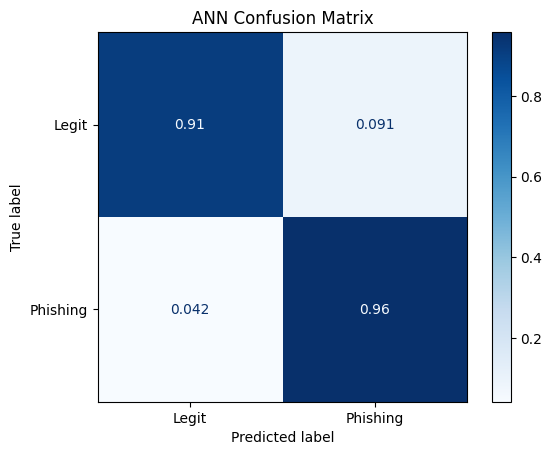

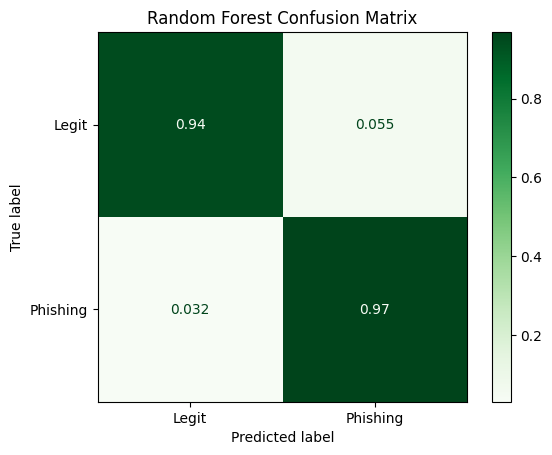

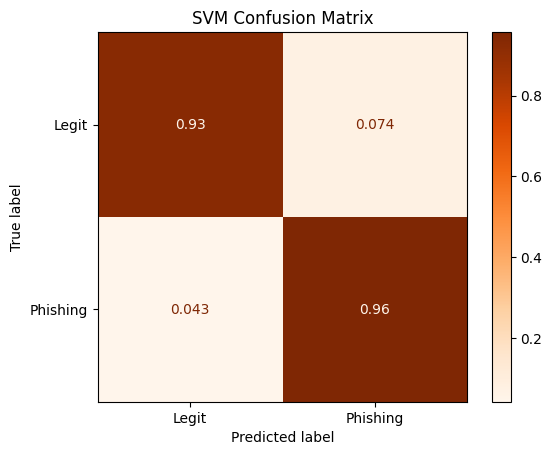

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

# ANN Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, ann_pred, display_labels=['Legit', 'Phishing'], cmap='Blues', normalize='true')
plt.title("ANN Confusion Matrix")
plt.show()

# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=['Legit', 'Phishing'], cmap='Greens', normalize='true')
plt.title("Random Forest Confusion Matrix")
plt.show()

# SVM Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, svm_pred, display_labels=['Legit', 'Phishing'], cmap='Oranges', normalize='true')
plt.title("SVM Confusion Matrix")
plt.show()



In [13]:
from sklearn.metrics import classification_report

print("🔸 ANN Classification Report:\n", classification_report(y_test, ann_pred))
print("🔸 Random Forest Classification Report:\n", classification_report(y_test, rf_pred))
print("🔸 SVM Classification Report:\n", classification_report(y_test, svm_pred))


🔸 ANN Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.91      0.93       976
           1       0.93      0.96      0.94      1235

    accuracy                           0.94      2211
   macro avg       0.94      0.93      0.94      2211
weighted avg       0.94      0.94      0.94      2211

🔸 Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95       976
           1       0.96      0.97      0.96      1235

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211

🔸 SVM Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.94       976
           1       0.94      0.96      0.95      1235

    accuracy                           0.94      2211
   macro avg       0.94     

In [15]:
summary = {
    'Model': ['ANN', 'Random Forest', 'SVM'],
    'AUC Score': [ann_auc, rf_auc, svm_auc],
    'Accuracy (%)': [
        accuracy_score(y_test, ann_pred) * 100,
        accuracy_score(y_test, rf_pred) * 100,
        accuracy_score(y_test, svm_pred) * 100
    ]
}

summary_df = pd.DataFrame(summary)
print(summary_df)


           Model  AUC Score  Accuracy (%)
0            ANN   0.984175     93.622795
1  Random Forest   0.989937     95.793758
2            SVM   0.985754     94.346450


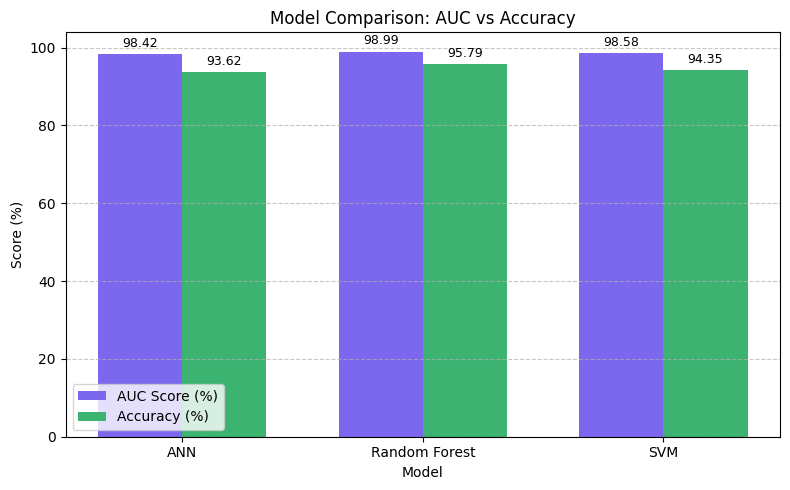

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = summary_df['Model']
auc_scores = summary_df['AUC Score']
accuracy_scores = summary_df['Accuracy (%)']

x = np.arange(len(models))  # label locations
width = 0.35  # width of the bars

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, auc_scores * 100, width, label='AUC Score (%)', color='mediumslateblue')
bars2 = ax.bar(x + width/2, accuracy_scores, width, label='Accuracy (%)', color='mediumseagreen')

# Add text labels above bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

# Customizing
ax.set_xlabel('Model')
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison: AUC vs Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [17]:
X = df.drop('class', axis=1)
y = df['class']

print(X.columns.tolist())


['Index', 'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport']


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics
precision = [
    precision_score(y_test, ann_pred),
    precision_score(y_test, rf_pred),
    precision_score(y_test, svm_pred)
]

recall = [
    recall_score(y_test, ann_pred),
    recall_score(y_test, rf_pred),
    recall_score(y_test, svm_pred)
]

f1 = [
    f1_score(y_test, ann_pred),
    f1_score(y_test, rf_pred),
    f1_score(y_test, svm_pred)
]

# Add to summary_df
summary_df["Precision"] = precision
summary_df["Recall"] = recall
summary_df["F1-Score"] = f1

# Show final summary
print("\n🔎 Final Model Performance Summary:")
print(summary_df)



🔎 Final Model Performance Summary:
           Model  AUC Score  Accuracy (%)  Precision    Recall  F1-Score
0            ANN   0.984175     93.622795   0.930031  0.957895  0.943757
1  Random Forest   0.989937     95.793758   0.956800  0.968421  0.962575
2            SVM   0.985754     94.346450   0.942584  0.957085  0.949779
